# DeepWalk. Node2vec.

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Макрушин С.В. "Случайные блуждания на графах"
* Документация:
    * https://radimrehurek.com/gensim/models/word2vec.html
    * https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html
    * https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html
    * http://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html
    
* Дополнительные источники:
    * https://memgraph.com/blog/how-node2vec-works
    * https://github.com/eliorc/node2vec

## Вопросы для совместного обсуждения

1\. Обсудите принцип работы алгоритмов DeepWalk и Node2vec и рассмотрите примеры обучения модели word2vec при помощи пакета `gensim`.

## Задачи для самостоятельного решения

In [5]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from typing import List, Dict, Any
from collections import Counter

from gensim.models import Word2Vec
from sklearn.neural_network import MLPClassifier
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score
from node2vec import Node2Vec

np.random.seed(42)

<p class="task" id="1"></p>

1\. Напишите функцию `generate_walk`, которая принимает на вход граф `G`, начальный узел `node` и генерирует случайное блуждание длины `walk_len`, начинающееся с этого узла. Сгенерируйте реализации 1000 случайных блужданий длины 3 с началом в случайно выбранных узлах для карате клуба. 

Используя полученные последовательности узлов, обучите модель Word2Vec из пакета `gensim` со следующими гиперпараметрами: размерность эмбеддингов 32, ширина контекстного окна 3.

Получите эмбеддинги узлов и уменьшите их размерность до 2 при помощи алгоритмов PCA или t-SNE. Визуализируйте граф, используя эмбеддинги размерности 2 в качестве координат узлов. Раскрасьте узлы в цвет соответствующего им клуба.

- [ ] Проверено на семинаре

In [8]:
def generate_walk(G: nx.Graph, node: int, walk_len: int) -> List[str]:
    walk = [str(node)]
    current_node = node
    
    for _ in range(walk_len - 1): 
        neighbors = list(G.neighbors(current_node))
        if not neighbors:
            break
        next_node = np.random.choice(neighbors)
        walk.append(str(next_node))
        current_node = next_node
        
    return walk


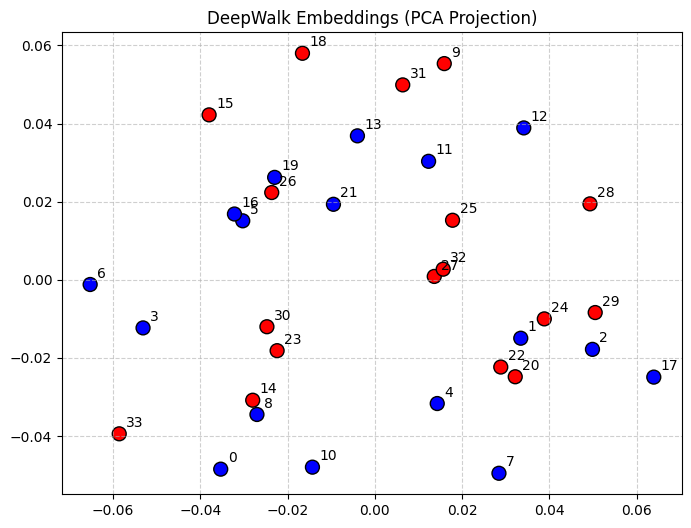

In [9]:

G = nx.karate_club_graph()
nodes = list(G.nodes())

num_walks = 1000
walk_len = 3
walks = []

for _ in range(num_walks):
    start_node = np.random.choice(nodes)
    walks.append(generate_walk(G, start_node, walk_len))

model_dw = Word2Vec(sentences=walks, vector_size=32, window=3, sg=1, min_count=1, workers=4)

embeddings_dw = np.array([model_dw.wv[str(n)] for n in nodes]) # [34, 32]
labels = [G.nodes[n]['club'] for n in nodes]
colors = ['red' if club == 'Officer' else 'blue' for club in labels]

pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings_dw) # [34, 2]

# 6. Визуализация
plt.figure(figsize=(8, 6))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c=colors, s=100, edgecolors='k')
for i, node in enumerate(nodes):
    plt.annotate(str(node), (embeddings_2d[i, 0], embeddings_2d[i, 1]), xytext=(5, 5), textcoords='offset points')
plt.title("DeepWalk Embeddings (PCA Projection)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<p class="task" id="2"></p>

2\. Используя нейронную сеть (можно воспользоваться реализацией из `sklearn` или `torch`) с одним скрытым слоем на 16 нейронов, решите задачу классификации узлов графа. В качестве признаков используйте эмбеддинги узлов, полученные в предыдущей задаче (до уменьшения размерности), в качестве меток - названия клубов узлов. Выведите на экран accuracy полученной модели.

- [ ] Проверено на семинаре

In [17]:
X = embeddings_dw
y = np.array([0 if club == 'Mr. Hi' else 1 for club in labels]) # [34]

clf = MLPClassifier(hidden_layer_sizes=(16,), activation='relu', max_iter=1000, random_state=42)

clf.fit(X, y)

y_pred = clf.predict(X)
acc = accuracy_score(y, y_pred)

print(f"Accuracy классификации узлов по эмбеддингам DeepWalk: {acc * 100:.2f}%")

Accuracy классификации узлов по эмбеддингам DeepWalk: 97.06%


c:\Users\Rog G16\.conda\envs\FU\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1000) reached and the optimization hasn't converged yet.
  warnings.warn(


<p class="task" id="3"></p>

3\. Напишите функцию `generate_biased_walk`, которая принимает на вход граф `G`, начальный узел `node` и генерирует смещенное случайное блуждание длины `walk_len`, начинающееся с этого узла. 

![](https://i.imgur.com/CtnVJFJ.png)

Сгенерируйте реализации 1000 случайных блужданий длины 3 с началом в случайно выбранных узлах. 

- [ ] Проверено на семинаре

In [19]:
def generate_biased_walk(G: nx.Graph, node: int, walk_len: int, p: float, q: float) -> List[str]:
    walk = [node]
    
    for step in range(walk_len - 1):
        current = walk[-1]
        neighbors = list(G.neighbors(current))
        
        if not neighbors:
            break
            
        if step == 0:
            next_node = np.random.choice(neighbors)
        else:
            prev = walk[-2]
            unnormalized_probs = []
            
            for neighbor in neighbors:
                if neighbor == prev:
                    unnormalized_probs.append(1.0 / p)
                elif G.has_edge(neighbor, prev):
                    unnormalized_probs.append(1.0)
                else:
                    unnormalized_probs.append(1.0 / q)
            
            unnormalized_probs = np.array(unnormalized_probs)
            probs = unnormalized_probs / unnormalized_probs.sum()
            
            next_node = np.random.choice(neighbors, p=probs)
            
        walk.append(next_node)
        
    return [str(n) for n in walk]


In [20]:
biased_walks = []
for _ in range(1000):
    start_node = np.random.choice(nodes)
    biased_walks.append(generate_biased_walk(G, start_node, walk_len=3, p=1, q=2))

print("Пример одного смещенного блуждания:", biased_walks[0])

Пример одного смещенного блуждания: ['30', '1', '0']


<p class="task" id="4"></p>

4\. Сгенерируйте реализации 1000 смещенных случайных блужданий длины 5 с началом в случайно выбранных узлах с параметрами `p=1` и `q=2`. 

Используя полученные последовательности узлов, обучите модель Word2Vec из пакета `gensim` со следующими гиперпараметрами: размерность эмбеддингов 32, ширина контекстного окна 3.

Получите эмбеддинги узлов и уменьшите их размерность до 2 при помощи алгоритмов PCA или t-SNE. Визуализируйте граф, используя эмбеддинги размерности 2 в качестве координат узлов. Раскрасьте узлы в цвет соответствующего им клуба.

- [ ] Проверено на семинаре

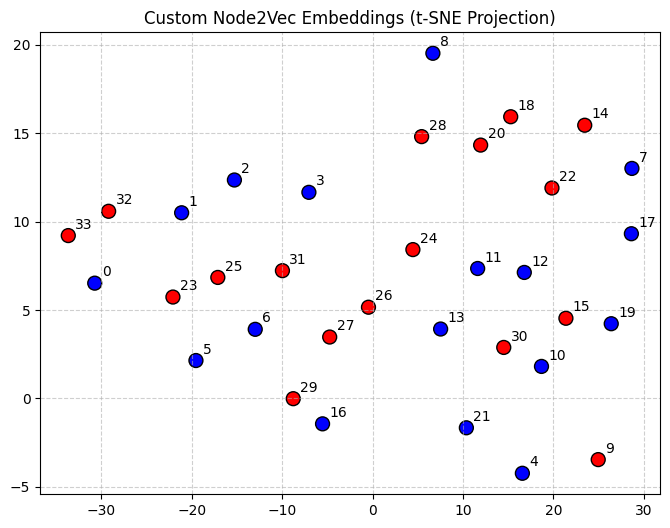

In [21]:
biased_walks_len5 = []
for _ in range(1000):
    start_node = np.random.choice(nodes)
    biased_walks_len5.append(generate_biased_walk(G, start_node, walk_len=5, p=1.0, q=2.0))

model_n2v_custom = Word2Vec(sentences=biased_walks_len5, vector_size=32, window=3, sg=1, min_count=1, workers=4)

embeddings_n2v_custom = np.array([model_n2v_custom.wv[str(n)] for n in nodes]) # [34, 32]

tsne = TSNE(n_components=2, perplexity=10, random_state=42)
embeddings_tsne = tsne.fit_transform(embeddings_n2v_custom)

plt.figure(figsize=(8, 6))
plt.scatter(embeddings_tsne[:, 0], embeddings_tsne[:, 1], c=colors, s=100, edgecolors='k')
for i, node in enumerate(nodes):
    plt.annotate(str(node), (embeddings_tsne[i, 0], embeddings_tsne[i, 1]), xytext=(5, 5), textcoords='offset points')
plt.title("Custom Node2Vec Embeddings (t-SNE Projection)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

<p class="task" id="5"></p>

5\. Используя  [готовую реализацию node2vec](https://github.com/eliorc/node2vec), обучите модель с гиперпараметрами, аналогичными предыдущей задачи. Получите эмбеддинги узлов и уменьшите их размерность до 2 при помощи алгоритмов PCA или t-SNE. Визуализируйте граф, используя эмбеддинги размерности 2 в качестве координат узлов. Раскрасьте узлы в цвет соответствующего им клуба.

- [ ] Проверено на семинаре

Computing transition probabilities: 100%|██████████| 34/34 [00:00<00:00, 16106.43it/s]


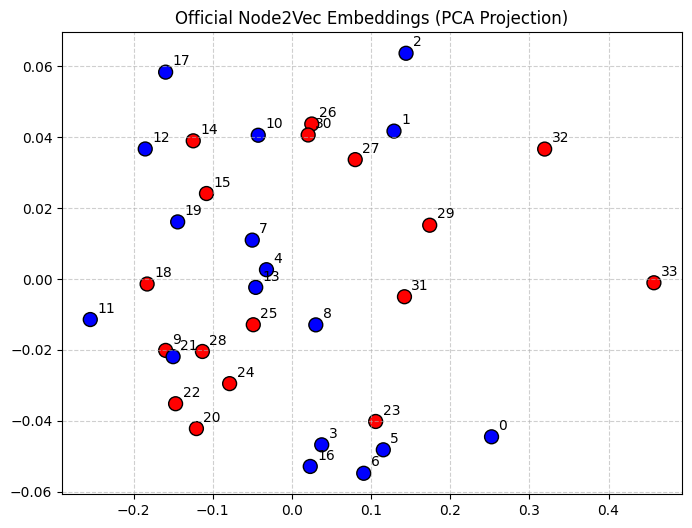

In [24]:
node2vec = Node2Vec(
    G, 
    dimensions=32, 
    walk_length=5, 
    num_walks=30,
    p=1.0, 
    q=2.0, 
    workers=4, 
    # quiet=True 
)

model_official = node2vec.fit(window=3, min_count=1)

embeddings_official = np.array([model_official.wv[str(n)] for n in nodes])

pca_official = PCA(n_components=2)
embeddings_official_2d = pca_official.fit_transform(embeddings_official)

plt.figure(figsize=(8, 6))
plt.scatter(embeddings_official_2d[:, 0], embeddings_official_2d[:, 1], c=colors, s=100, edgecolors='k')
for i, node in enumerate(nodes):
    plt.annotate(str(node), (embeddings_official_2d[i, 0], embeddings_official_2d[i, 1]), xytext=(5, 5), textcoords='offset points')
plt.title("Official Node2Vec Embeddings (PCA Projection)")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()